This notebook tackles the [**Playground Series – Season 6, Episode 2: Predicting Heart Disease**](https://www.kaggle.com/competitions/playground-series-s6e2), a competition focused on predicting if a patient has heart disease, based on features describing the patient's demographics and selected health metrics.

## The Approach

I plan to split the various phases of model development into a separate notebooks to streamline later work (EDA can be *time consuming*), and allow conducting multiple studies at one time.  We will follow a structured machine learning workflow across several notebooks:

1.  **Exploratory Data Analysis (EDA):** We will begin by conducting a deep dive into the dataset using `ydata_profiling` and custom visualizations. This will help us understand the data's structure, identify patterns, analyze feature distributions, check for correlations, and assess overall data quality.  **(This notebook)**
    
2.  **Data Preprocessing & Feature Engineering:** Based on insights from the EDA, we will prepare the data for modeling. This will involve strategies like encoding categorical variables and splitting combined features to extract maximum predictive value.  A `FeatureEngineering` utility class will be created so that strategies can be shared among the various model notebooks.
    
3.  **Model Development & Tuning:** Once we have evaluated the data and performed feature engineering, we will build and train a robust predictive model. In past competitions, we've started with a **LightGBM** (Light Gradient Boosting Machine) model, renowned for its high performance and efficiency. We will also leverage **Optuna** for automated hyperparameter tuning to find the best-performing model configuration.  In the last competition, I also added notebooks to train **XGBoost** and **CatBoost** models.  I will also develop a model-blending notebook to blend the predictions, which provided the best scores.
    
4.  **Submission:** Finally, we will use our tuned model to generate predictions (probabilities) on the test set and format them into a `submission.csv` file for the competition.
    
Let's begin by loading the necessary libraries and exploring the data.

## Install Needed Packages

In [1]:
%pip -q install --upgrade ydata_profiling


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
from IPython.display import display
from ydata_profiling import ProfileReport
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e02_experiment_setup import ExperimentSetup
from ps_s06e02_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Heart Disease'

# Show GPU be utilized in training
USE_GPU = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1          3.600            2   
1     171                0          0.000            1   
2     151                0          0.000            1   
3     150                0          1.000            2   
4     125                1          3.800            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3    

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1          0.800            2   
1            0     172                0          0.000            1   
2            0     150                1          0.000            2   
3            0     168                0          0.900            1   
4            0     163                0          1.800            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2        

## Read and Examine the Original Dataset

In [6]:
original_df = helper.read_dataset('original')

ORIGINAL DATASET

   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0          2.400            2   
1     160                0          1.600            2   
2     141                0          0.300            1   
3     105                1          0.200            2   
4     121                1          0.200            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2          

## Exploratory Data Analysis

In a previous Playground Episode, I ran across a report generator that shows histograms, tables of most common values, and various interaction plots.  Even better, it can be used to determine if the test dataset differs from the training set, and if so, how.  I spent hours poring over them, and they helped to determine which columns to concentrate on for feature engineering.  And since it creates an HTML report, it can be viewed outside the notebook, from github, for instance.

In [7]:
# Create the profile report object for the TRAINING data
training_report = ProfileReport(training_df, title='Training Data')

# Create the profile report object for the TEST data
test_report = ProfileReport(test_df, title='Test Data')

# Create the comparison report
# This compares the TEST report *against* the TRAINING report
train_test_comparison_report = training_report.compare(test_report)

# Save the combined report to an HTML file
train_test_comparison_report.to_file('training_vs_test_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:02<00:00,  5.78it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 12.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Display the HTML report in an iframe
IFrame(src='training_vs_test_comparison.html', width=1000, height=600)

We also load the original dataset to compare distributions. Note: Ensure you have added the [Heart Disease Prediction Dataset](/kaggle/input/heartdisease/Heart_Disease_Prediction.csv) to your notebook input for this cell to run.

In [9]:
# Create the profile report object for the ORIGINAL data
original_report = ProfileReport(test_df, title='Original Data')

# Create the comparison report
# This compares the ORIGINAL report *against* the TRAINING report
train_original_comparison_report = training_report.compare(original_report)

# Save the combined report to an HTML file
train_original_comparison_report.to_file('training_vs_original_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 16.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Display the HTML report in an iframe
IFrame(src='training_vs_original_comparison.html', width=1000, height=600)

## Data Visualization
While the automated report provides a great overview, we will use a custom `DataVisualizer` class to dig deeper into specific relationships.

1. **Target Encoding:** We convert the `Heart Disease` target from 'Absence'/'Presence' to `0` and `1`. This allows us to calculate mean risk rates and correlations numerically.
2. **Signal Ranking:** We will rank features by their Spearman correlation (for numerical features) and range of risk (for categorical features) to identify the strongest predictors.
3. **Interaction Plots:** We will generate specific plots to see how top features interact with the target.

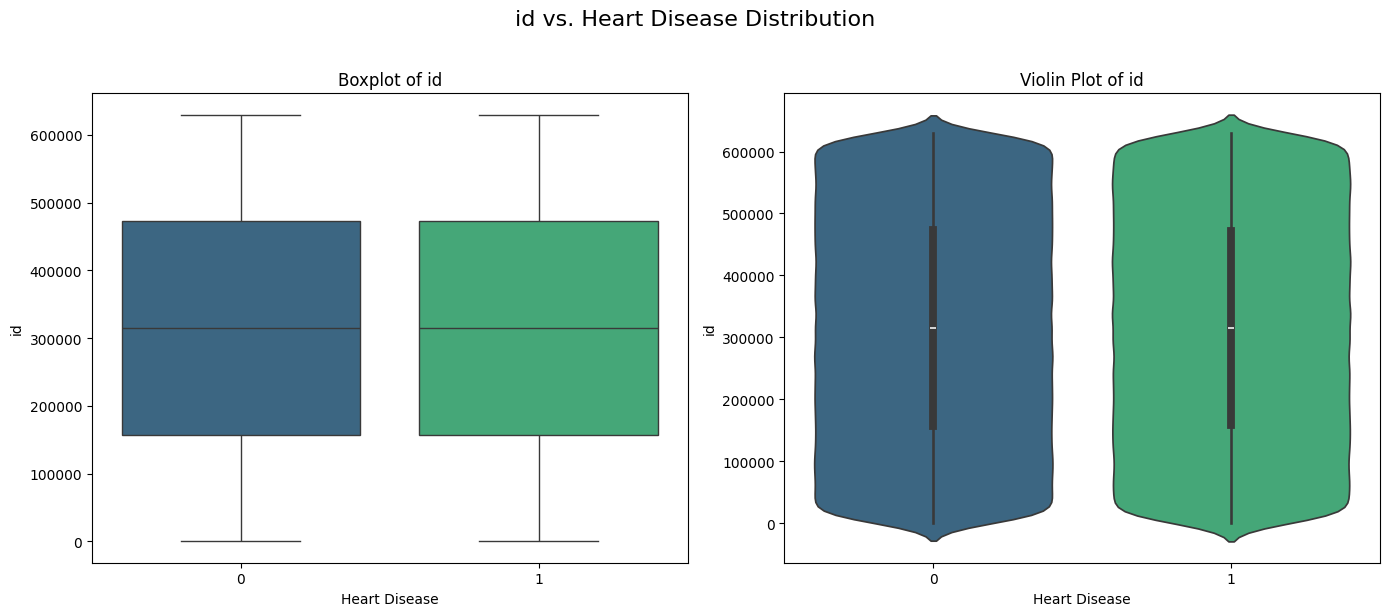

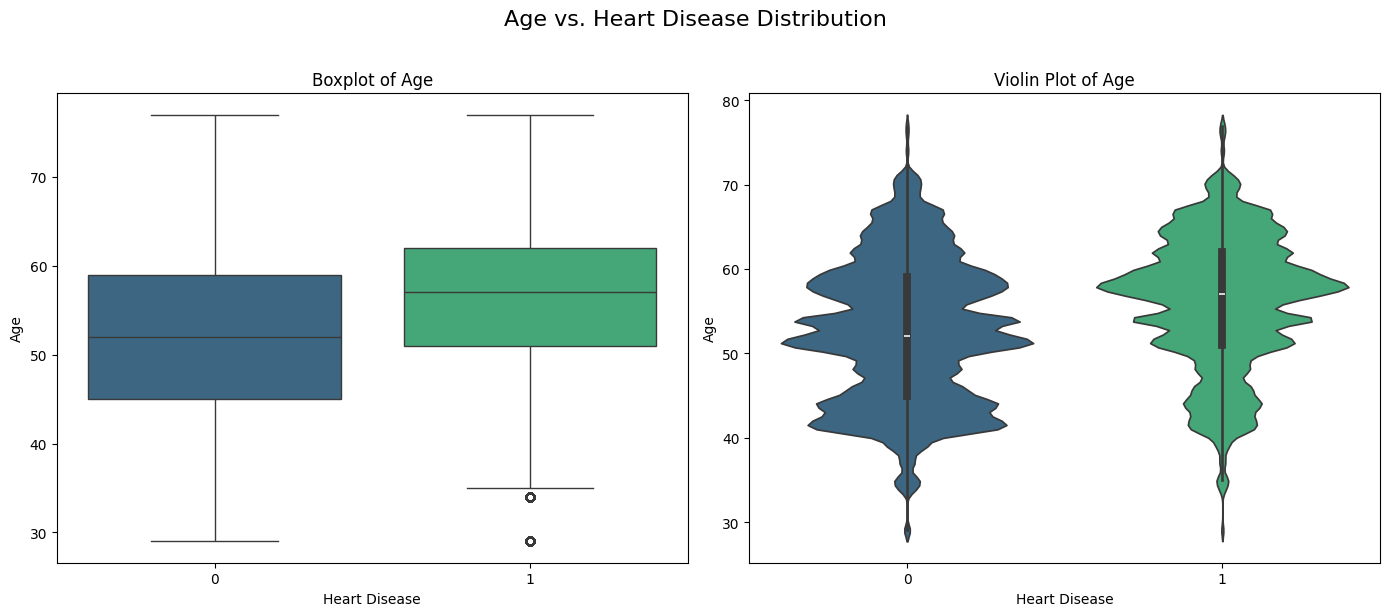

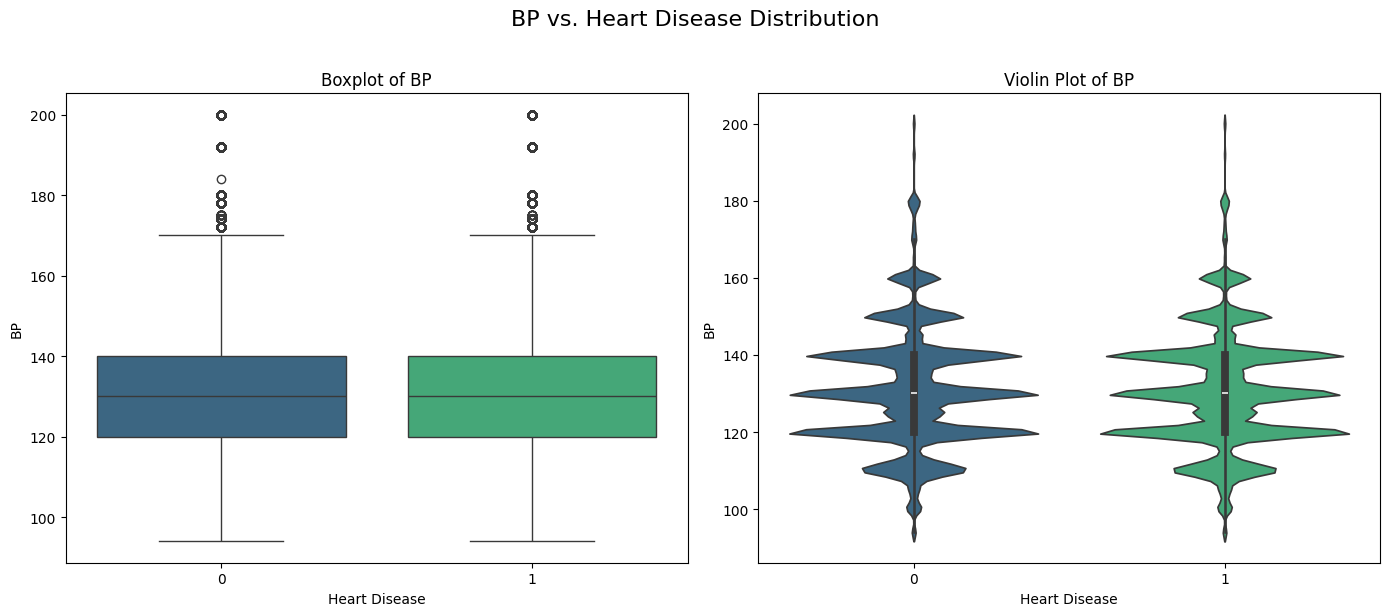

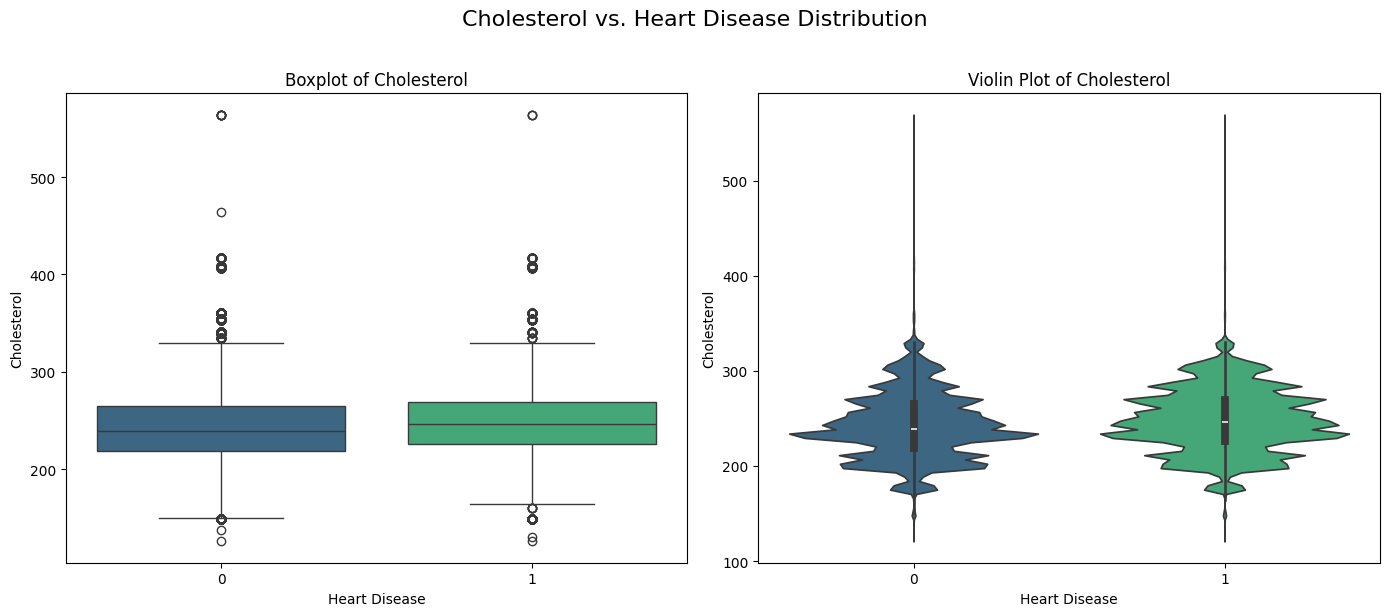

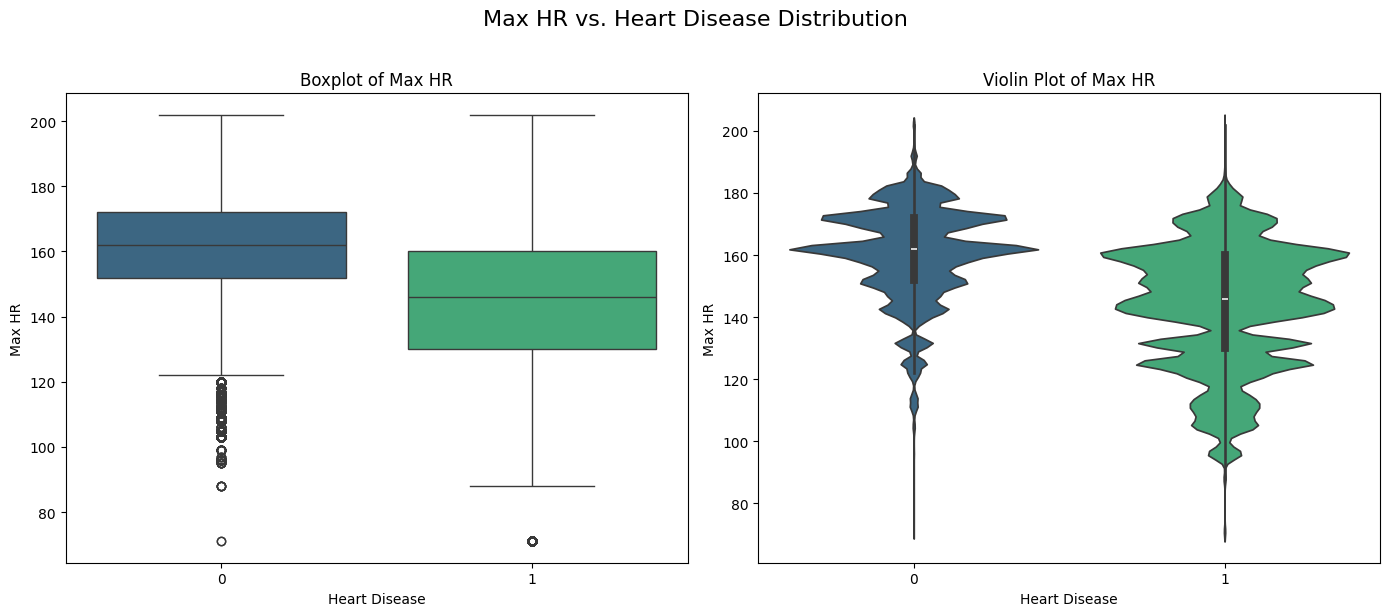

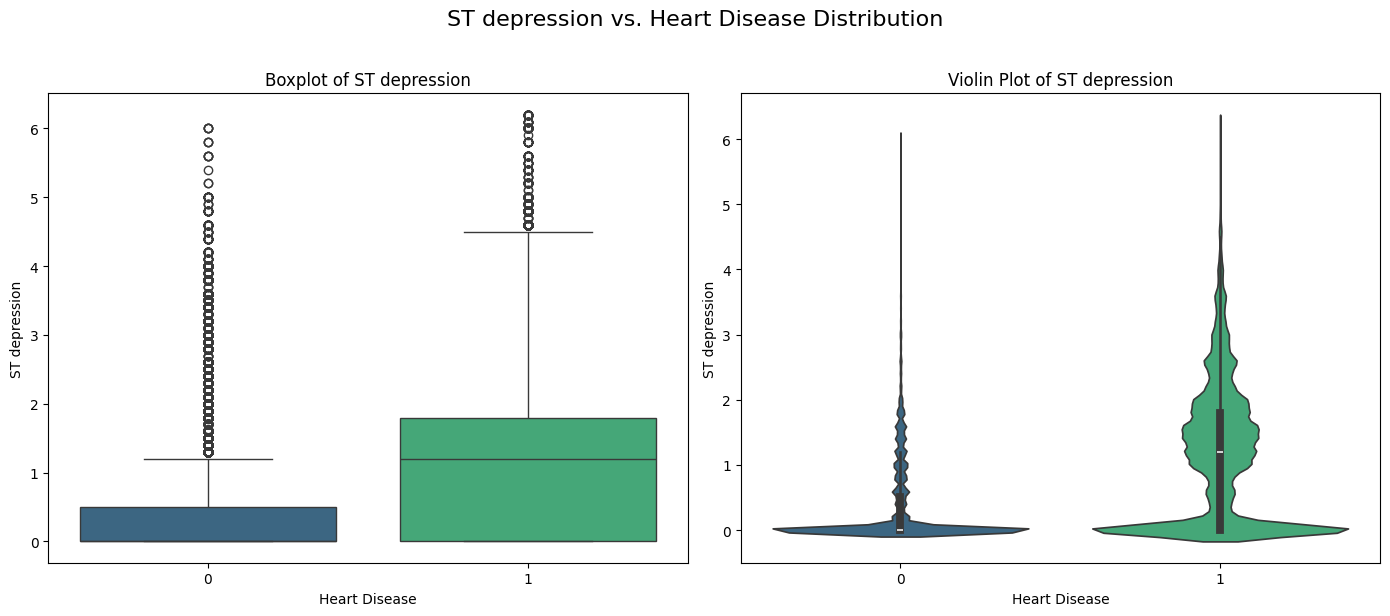

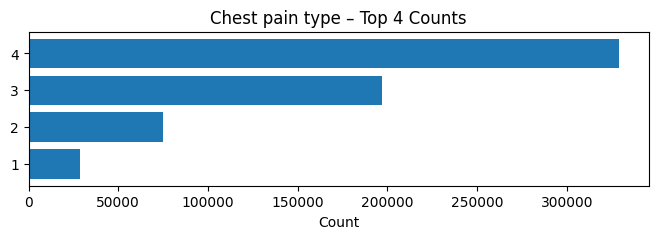

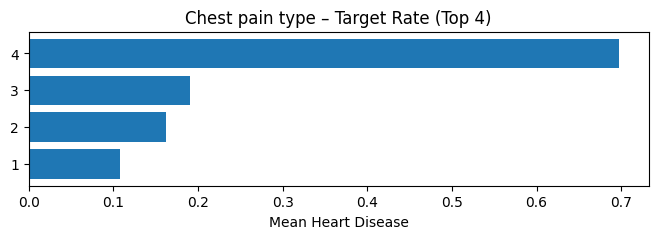

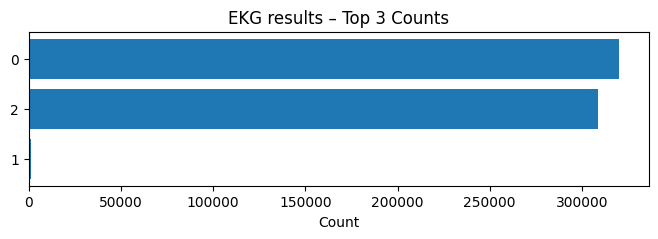

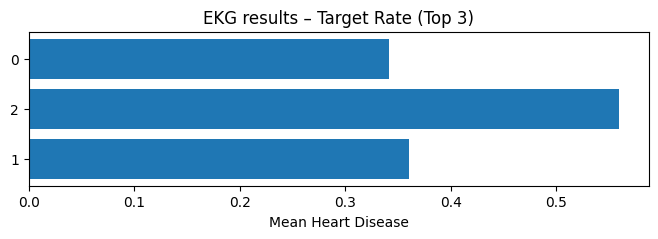

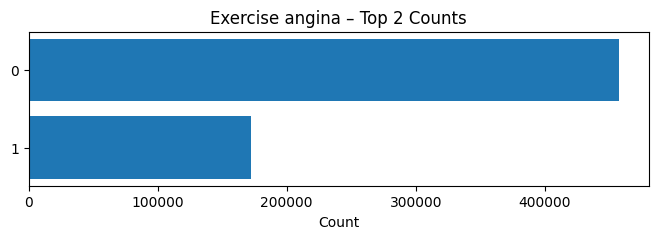

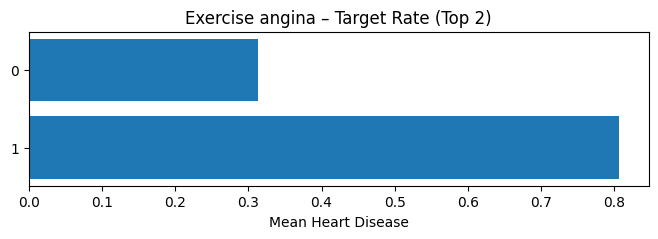

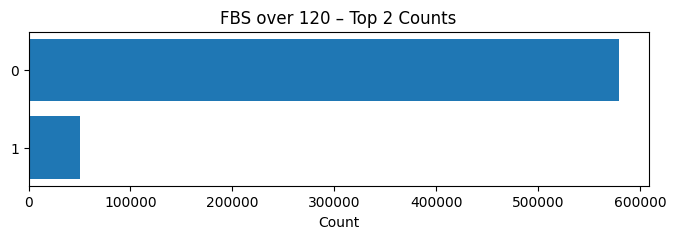

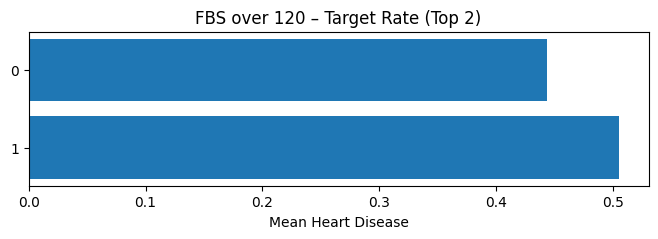

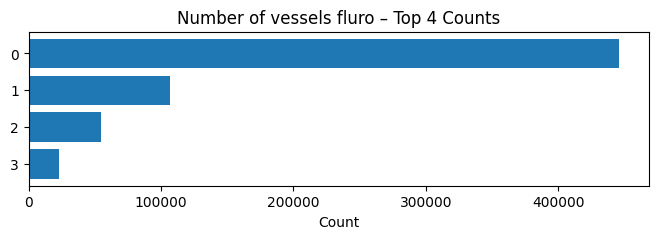

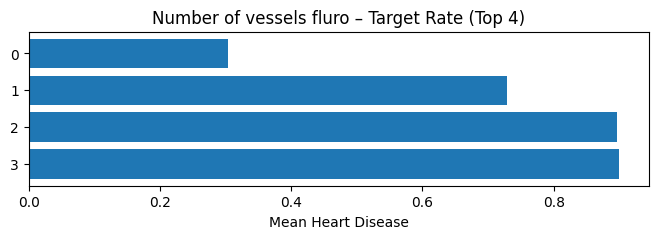

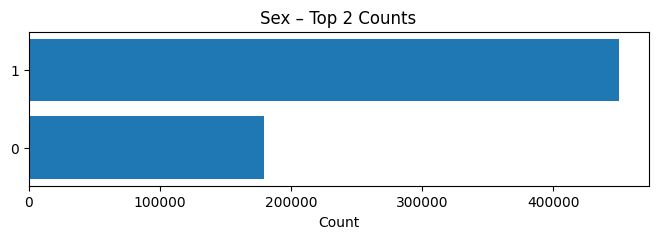

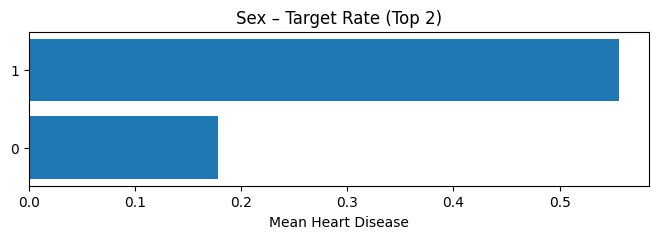

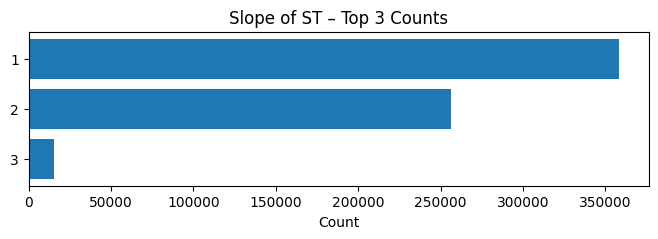

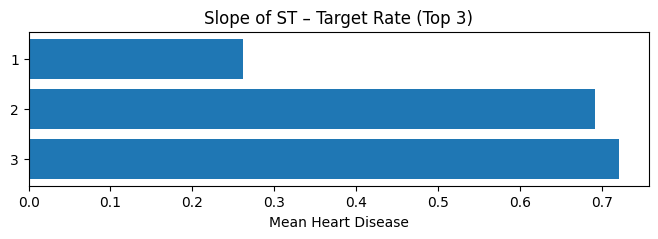

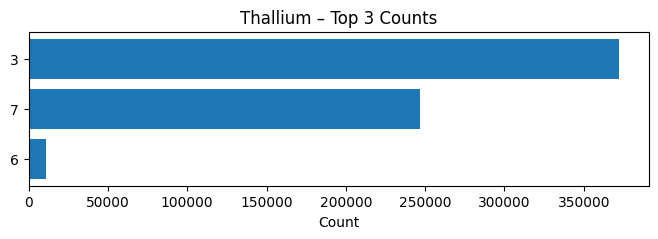

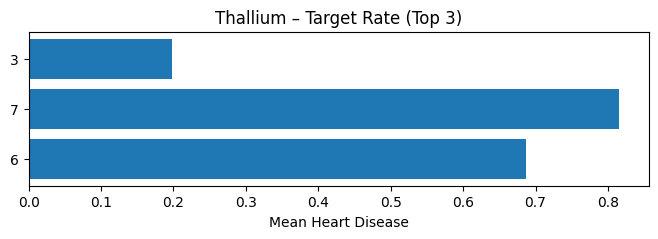

### Numeric x Category Trend

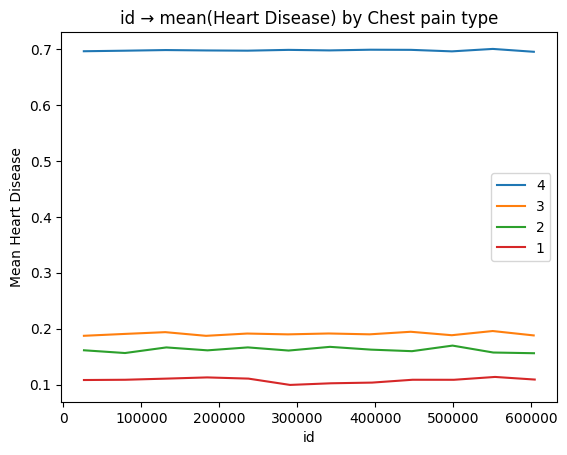

### Category x Category Trend

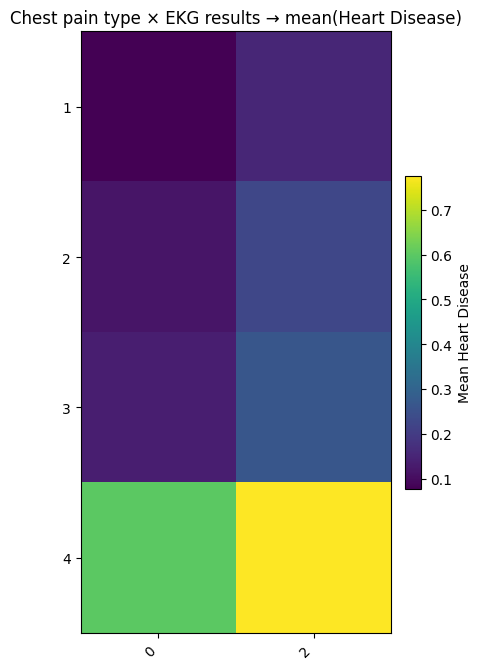

### Feature Signal Ranking

Top numeric (|Spearman|): [('Thallium', 0.6050033052740508), ('Chest pain type', 0.5088761081262959), ('Number of vessels fluro', 0.46269045745764226), ('Exercise angina', 0.44186373145061997), ('Max HR', -0.4410490524951035), ('ST depression', 0.43048525622230577), ('Slope of ST', 0.4271084127449015), ('Sex', 0.3424462590920789), ('EKG results', 0.2189542756645143), ('Age', 0.21667877158885415)]
Top categorical (range of mean risk): []


In [11]:
# Convert target to 0 and 1
# This allows .mean() to calculate the "percentage of Heart Disease"
df = training_df.copy()
df['Heart Disease'] = df['Heart Disease'].map({
    'Absence': 0, 
    'Presence': 1
})

visualizer = DataVisualizer(target=TARGET, seed=helper.get_seed())
visualizer.run_data_visualization(df)